# Weather-Aware Fine-Tuning

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import torch

import pandas as pd
import torch.nn as nn

from utils_io import load_image
from torch.utils.data import Dataset, DataLoader
from transformers import ViTImageProcessor, ViTForImageClassification

ImportError: cannot import name 'ExportOptions' from 'torch.onnx._internal.exporter' (/Users/huwx/miniconda3/envs/venv_torch/lib/python3.11/site-packages/torch/onnx/_internal/exporter/__init__.py)

## Simple Evaluation of a Pre-Trained Model

In [3]:
csv_path = '/Users/huwx/Desktop/weather/csv/cam_id_7410_F.csv'
image_path = '/Users/huwx/Desktop/weather/images/7410'

df = pd.read_csv(csv_path)

In [4]:
# Demo image
# url = 'http://images.cocodataset.org/test-stuff2017/000000005258.jpg'

# Random image from our database
url = df.sample().iloc[0].url

image = load_image(url)
# image

2025-07-31 14:51:52,707 [INFO] Downloading image from https://weatherusa.s3.wasabisys.com/cams/7410/20250317/snap_7410_20250317_021506_4da55dd0.jpg


In [5]:
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

In [6]:
inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits

In [7]:
# model predicts one of the 1000 ImageNet classes
predicted_class_idx = logits.argmax(-1).item()
print("Predicted class:", model.config.id2label[predicted_class_idx])

Predicted class: fountain


## Model Fine Tuning

In [8]:
class WeatherDataset(Dataset):
    def __init__(self, csv_file, image_path, processor=None, bar_height=90, split=None):
        self.df = pd.read_csv(csv_file)

        self.mean = 67.25816631962519
        self.std = 15.428722278520402
        self.df['temperature'] = (self.df.temperature - self.mean) / self.std

        if isinstance(split, tuple):
            start, end = split
            self.df = self.df.iloc[start:end]

        self.image_path = image_path
        self.processor = processor
        self.bar_height = bar_height

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        image = load_image(row['url'], tmp_dir=self.image_path)
        width, height = image.size
        cropped_image = image.crop((0, 0, width, height - self.bar_height))

        if self.processor is None:
            pixel_values = torch.tensor(np.array(cropped_image).transpose((2, 0, 1)), dtype=torch.float32) / 255.0
        else:
            # Process for model
            inputs = self.processor(images=cropped_image, return_tensors="pt")
            pixel_values = inputs['pixel_values'].squeeze(0)
        
        # Get temperature target
        temperature = torch.tensor(row['temperature'], dtype=torch.float32).reshape(-1)

        return {'pixel_values': pixel_values, 'target': temperature}

In [9]:
import torch
import torch.nn as nn

import pytorch_lightning as pl

from torch.optim import AdamW
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger


class WeatherRegressionModel(pl.LightningModule):
    def __init__(self, model_name='google/vit-base-patch16-224', learning_rate=1e-4):
        super().__init__()
        self.save_hyperparameters()
        
        # Load pre-trained model and modify for regression
        self.model = ViTForImageClassification.from_pretrained(model_name)
        input_dim = self.model.classifier.in_features
        self.model.classifier = nn.Linear(input_dim, 1)
        
        # Loss function
        self.criterion = nn.MSELoss()
        
        # For tracking metrics
        self.train_losses = []
        self.val_losses = []
        
    def forward(self, input):
        outputs = self.model(input)
        return outputs.logits

    def common_step(self, batch, batch_idx):
        pixel_values = batch['pixel_values']
        targets = batch['target']
        
        # Forward pass
        predictions = self(pixel_values)
        loss = self.criterion(predictions, targets)
        
        return loss
    
    def training_step(self, batch, batch_idx):
        loss = self.common_step(batch, batch_idx)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self.common_step(batch, batch_idx)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)

    def predict_step(self, batch, batch_idx):
        pixel_values = batch['pixel_values']
        with torch.no_grad():
            predictions = self(pixel_values)
        return predictions

    def configure_optimizers(self):
        # Different learning rates for backbone vs classifier
        optimizer = AdamW([
            {'params': self.model.vit.parameters(), 'lr': self.hparams.learning_rate * 0.1},  # Lower for pre-trained
            {'params': self.model.classifier.parameters(), 'lr': self.hparams.learning_rate}  # Higher for new layer
        ], weight_decay=0.01)
        
        # Optional: Learning rate scheduler
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10,
        )
        
        return {
            'optimizer': optimizer,
            # 'lr_scheduler': {
            #     'scheduler': scheduler,
            #     'monitor': 'val_loss'
            # }
        }

In [10]:
dataset = WeatherDataset(csv_file=csv_path, image_path=image_path, processor=processor, split=(0, 128))
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
model = WeatherRegressionModel()

In [19]:
logger_tb = TensorBoardLogger(save_dir='lightning_logs', name='FineTunedViT')
trainer = Trainer(max_epochs=10, gradient_clip_val=0.1, logger=logger_tb)
trainer.fit(model, dataloader)

2025-07-31 14:52:31,593 [INFO] 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
2025-07-31 14:52:31,599 [INFO] GPU available: True (mps), used: True
2025-07-31 14:52:31,599 [INFO] TPU available: False, using: 0 TPU cores
2025-07-31 14:52:31,600 [INFO] HPU available: False, using: 0 HPUs
/Users/huwx/miniconda3/envs/venv_torch/lib/python3.11/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
2025-07-31 14:52:31,698 [INFO] 
  | Name      | Type                      | Params | Mode 
----------------------------------------------------------------
0 | model     | ViTForImageClassification | 85.8 M | eval 
1 | criterion | MSELoss                   | 0      | train
----------------------------------------------------------------
85.8 M    T

Training: |          | 0/? [00:00<?, ?it/s]

2025-07-31 14:54:34,230 [INFO] `Trainer.fit` stopped: `max_epochs=10` reached.


In [20]:
test_dataset = WeatherDataset(csv_file=csv_path, image_path=image_path, processor=processor, split=(641, 720))
test_dataloader = DataLoader(test_dataset, batch_size=8)

In [21]:
predictions = trainer.predict(model, test_dataloader)
predictions = torch.cat(predictions, dim=0).detach().cpu().numpy().squeeze()
targets = test_dataset.df['temperature'].values
predictions = predictions * test_dataset.std + test_dataset.mean
targets = targets * test_dataset.std + test_dataset.mean

/Users/huwx/miniconda3/envs/venv_torch/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [28]:
import matplotlib.pyplot as plt
import matplotlib as mpl

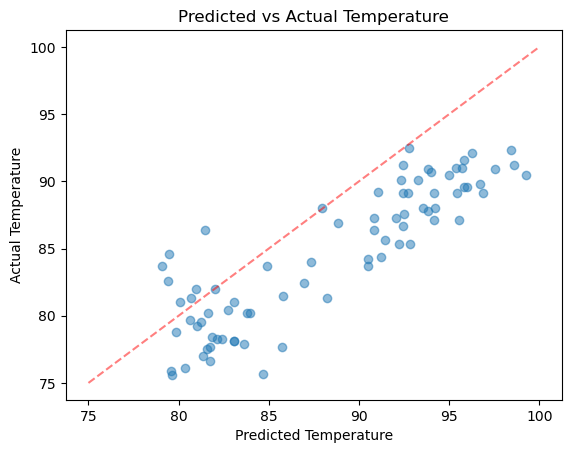

In [23]:
plt.plot(predictions, targets, 'o', alpha=0.5)
plt.plot([75, 100], [75, 100], 'r--', alpha=0.5)  # Diagonal line for perfect prediction
plt.xlabel('Predicted Temperature')
plt.ylabel('Actual Temperature')
plt.title('Predicted vs Actual Temperature')
plt.show()

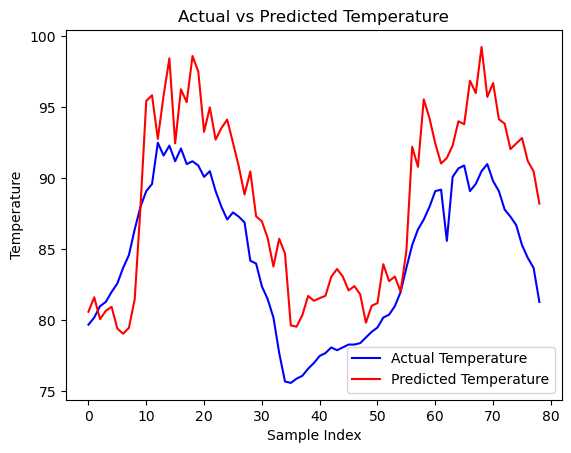

In [41]:
plt.plot(targets, label='Actual Temperature', color='blue')
plt.plot(predictions, label='Predicted Temperature', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Temperature')
plt.title('Actual vs Predicted Temperature')
plt.legend()
plt.show()

## Result Visualization

In [47]:
import numpy as np

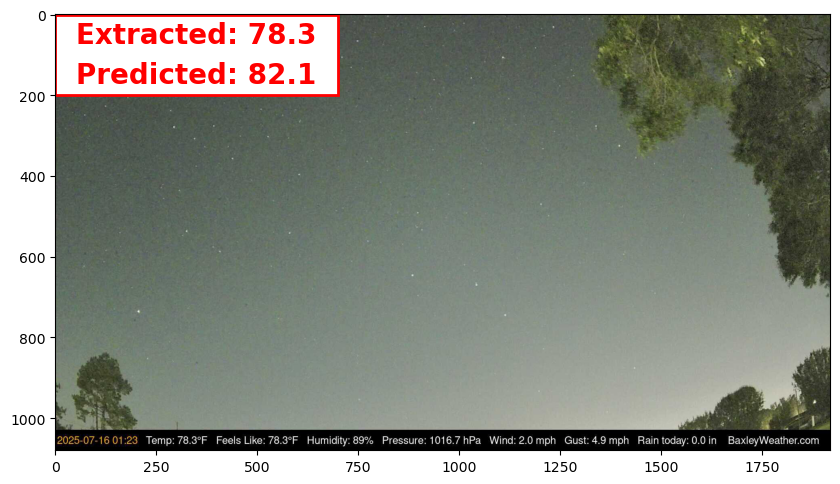

In [59]:
idx = np.random.randint(0, len(targets))

image = load_image(test_dataset.df.iloc[idx]['url'], tmp_dir=image_path)
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(image)

rec = mpl.patches.Rectangle((0, 0), 700, 200, edgecolor='red', facecolor='white', lw=2)
ax.add_patch(rec)

extracted = targets[idx]
predicted = predictions[idx]

ax.text(50, 50, f'Extracted: {extracted:0.1f}', color='red', fontsize=20, weight='bold', ha='left', va='center')
ax.text(50, 150, f'Predicted: {predicted:0.1f}', color='red', fontsize=20, weight='bold', ha='left', va='center');

### Interpretability

In [66]:
from captum.attr import IntegratedGradients, GradientShap, Occlusion
from captum.attr import visualization as viz
import torch
import numpy as np
import matplotlib.pyplot as plt

In [83]:
# Get one test sample
test_idx = 17
sample = test_dataset[test_idx]
pixel_values = sample['pixel_values'].unsqueeze(0)  # Add batch dimension
true_temp = sample['target'].item()

print(f"Input shape: {pixel_values.shape}")
print(f"True temperature: {true_temp:.3f}")

# Create baseline (black image)
baseline = torch.zeros_like(pixel_values)

# Initialize Integrated Gradients
ig = IntegratedGradients(model)

# Calculate attributions
model.eval()
attributions = ig.attribute(pixel_values, baseline, target=None, n_steps=50)

print(f"Attributions shape: {attributions.shape}")
print("Attribution calculation complete!")

Input shape: torch.Size([1, 3, 224, 224])
True temperature: 1.539
Attributions shape: torch.Size([1, 3, 224, 224])
Attribution calculation complete!


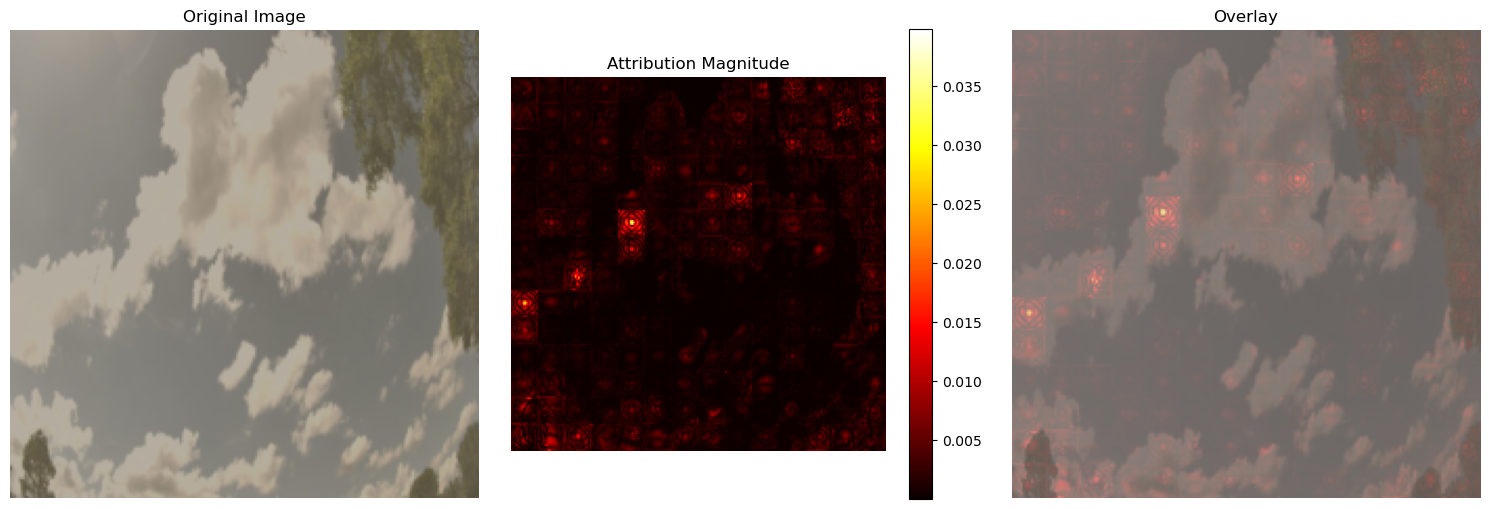

Model prediction: 1.821


In [84]:
# Convert to numpy for visualization
attr_np = attributions.squeeze().cpu().detach().numpy()
input_np = pixel_values.squeeze().cpu().detach().numpy()

# Transpose from (C, H, W) to (H, W, C)
attr_viz = np.transpose(attr_np, (1, 2, 0))
input_viz = np.transpose(input_np, (1, 2, 0))

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image (denormalized for display)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
input_denorm = input_viz * std + mean
input_denorm = np.clip(input_denorm, 0, 1)

axes[0].imshow(input_denorm)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Attribution magnitude
attr_magnitude = np.mean(np.abs(attr_viz), axis=2)
im = axes[1].imshow(attr_magnitude, cmap='hot')
axes[1].set_title('Attribution Magnitude')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1])

# Overlay
axes[2].imshow(input_denorm, alpha=0.6)
axes[2].imshow(attr_magnitude, cmap='hot', alpha=0.4)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Get model prediction
with torch.no_grad():
    pred = model(pixel_values).item()
print(f"Model prediction: {pred:.3f}")